# Skenario D — Pipeline Final Multi-Site (Sintesis & Penyempurnaan A+B+C)

**Proyek:** Sistem AI Monitoring & Prediksi Fluks Karbon Berbasis IoT  
**Perangkat IoT:** `AGRISENSE-CC-001`  
**Baseline terbaik sebelumnya:** Random Forest `R² = 0.613` (Skenario A)

Notebook ini adalah sintesis dan penyempurnaan menyeluruh dari Skenario A, B, dan C.
Setiap kelemahan yang ditemukan pada skenario sebelumnya sudah diperbaiki:

| Masalah di Skenario Sebelumnya | Perbaikan di Skenario D |
|---|---|
| `SW_IN` (radiasi) tidak ada di A & B | ✅ Disertakan sebagai fitur inti |
| `day` (1–31) tidak informatif musiman | ✅ Diganti dengan `day_of_year` + cyclical encoding |
| Tidak ada overfitting check | ✅ Train vs Test R² dicetak di semua model |
| Tidak ada cross-validation | ✅ `TimeSeriesSplit` 5-fold sebagai validasi robustness |
| `MANUAL_SITE_SOIL` kosong di Skenario C | ✅ Fallback otomatis + validasi nilai wajar |
| `soil_source` ikut masuk fitur model | ✅ Di-drop sebelum training |
| Mapping kolom terlalu lebar (semua TS_) | ✅ Seleksi kolom inti saja via `detect_first_available` |
| Tidak ada residual analysis | ✅ Plot residual vs predicted + distribusi error |
| Tidak ada evaluasi per site | ✅ Metrik dicetak per site_id |
| Hyperparameter tidak dituning | ✅ `RandomizedSearchCV` untuk RF dan XGBoost |
| Model hanya RF di Skenario B & C | ✅ RF + XGBoost dibandingkan di semua skenario |
| Tidak ada export model | ✅ Model terbaik diekspor ke `.pkl` + metadata JSON |

---
## Bagian 1 — Import Library & Konfigurasi

In [12]:
import warnings
warnings.filterwarnings('ignore')

import time
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import randint, uniform

from xgboost import XGBRegressor
from xgboost.core import XGBoostError

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Library berhasil di-import.')
print(f'Pandas  : {pd.__version__}')
print(f'Numpy   : {np.__version__}')

Library berhasil di-import.
Pandas  : 3.0.2
Numpy   : 2.4.4


In [13]:
# =============================================================
# KONFIGURASI — sesuaikan path file di sini
# =============================================================

BASELINE_R2 = 0.613   # R² terbaik Skenario A sebagai acuan
TRAIN_RATIO = 0.8
RANDOM_STATE = 42
CV_FOLDS = 5

# --- Path dataset AmeriFlux ---
SITE_CONFIG = {
    'US-Ne1': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne1_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne1_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.1651,
        'lon': -96.4766,
    },
    'US-Ne2': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne2_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne2_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.1649,
        'lon': -96.4701,
    },
    'US-Ne3': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne3_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne3_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.1797,
        'lon': -96.4397,
    },
}

# --- Path dataset WoSIS ---
WOSIS_PH_PATH   = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_PH.csv')
WOSIS_ORGC_PATH = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_orgc.csv')

# --- Nilai soil manual per site (isi setelah spatial join WoSIS) ---
# Nilai ini akan digunakan jika tersedia; fallback ke spatial join otomatis jika tidak.
# Contoh nilai berdasarkan literatur Nebraska Mead:
MANUAL_SITE_SOIL = {
    'US-Ne1': {'soil_ph': 6.10, 'soil_organic_carbon': 18.20},
    'US-Ne2': {'soil_ph': 6.35, 'soil_organic_carbon': 21.50},
    'US-Ne3': {'soil_ph': 5.95, 'soil_organic_carbon': 16.80},
}

# --- Output ---
OUTPUT_DIR = Path('output_skenario_d')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Konfigurasi dimuat.')
print(f'Output directory: {OUTPUT_DIR.resolve()}')

Konfigurasi dimuat.
Output directory: D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\output_skenario_d


---
## Bagian 2 — Fungsi Utilitas

In [14]:
# =============================================================
# UTILITAS UMUM
# =============================================================

def detect_first_available(columns, candidates):
    """Temukan kolom pertama yang cocok dari daftar kandidat (case-insensitive)."""
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def evaluate_regression(y_true, y_pred, label=''):
    """Hitung MAE, RMSE, R² dan cetak hasilnya."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  [{label}] MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def print_overfit_check(model, X_train, y_train, X_test, y_test, model_name):
    """Cetak train vs test R² untuk mendeteksi overfitting."""
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))
    gap      = train_r2 - test_r2
    status   = '✅ Baik' if gap < 0.10 else ('⚠️  Moderat' if gap < 0.20 else '❌ Overfit')
    print(f'  [{model_name}] Train R²={train_r2:.4f}  |  Test R²={test_r2:.4f}  |  Gap={gap:.4f}  →  {status}')
    return train_r2, test_r2, gap


def haversine_km(lat1, lon1, lat2, lon2):
    """Hitung jarak great-circle dalam kilometer menggunakan formula Haversine."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def detect_xgb_device():
    """Coba gunakan GPU untuk XGBoost; fallback ke CPU jika CUDA tidak tersedia."""
    try:
        probe_X = np.array([[0.0], [1.0], [2.0], [3.0]], dtype=np.float32)
        probe_y = np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32)
        probe_model = XGBRegressor(
            n_estimators=2,
            max_depth=2,
            tree_method='hist',
            device='cuda',
            n_jobs=1,
            verbosity=0,
        )
        probe_model.fit(probe_X, probe_y)
        print('XGBoost GPU terdeteksi. Training akan memakai CUDA.')
        return 'cuda'
    except (XGBoostError, ValueError, RuntimeError) as exc:
        print(f'GPU XGBoost tidak tersedia, fallback ke CPU. Detail: {exc}')
        return 'cpu'


print('Fungsi utilitas dimuat.')

Fungsi utilitas dimuat.


In [15]:
# =============================================================
# UTILITAS VISUALISASI
# =============================================================

def plot_feature_importance(model, feature_names, title='Feature Importance', top_n=20):
    """Plot feature importance dari model."""
    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, max(5, top_n * 0.35)))
    bars = plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue', edgecolor='none')
    plt.xlabel('Importance Score')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{title.replace(' ', '_').replace('/', '_')}.png", dpi=120)
    plt.show()
    return fi_df


def plot_residuals(y_test, y_pred, title='Residual Analysis', site_labels=None):
    """Plot residual vs predicted dan distribusi error."""
    residuals = np.array(y_test) - np.array(y_pred)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Plot 1: Residual vs Predicted
    ax = axes[0]
    if site_labels is not None:
        for site_id in np.unique(site_labels):
            mask = site_labels == site_id
            ax.scatter(np.array(y_pred)[mask], residuals[mask], alpha=0.2, s=3, label=site_id)
        ax.legend(markerscale=4, fontsize=8)
    else:
        ax.scatter(y_pred, residuals, alpha=0.2, s=3, color='steelblue')
    ax.axhline(0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Predicted carbon_flux')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title('Residual vs Predicted')

    # Plot 2: Distribusi residual
    ax2 = axes[1]
    ax2.hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax2.axvline(0, color='red', linewidth=1, linestyle='--')
    ax2.set_xlabel('Residual')
    ax2.set_ylabel('Frekuensi')
    ax2.set_title(f'Distribusi Residual\nMean={residuals.mean():.3f}  Std={residuals.std():.3f}')

    # Plot 3: Actual vs Predicted
    ax3 = axes[2]
    lims = [min(np.min(y_test), np.min(y_pred)), max(np.max(y_test), np.max(y_pred))]
    ax3.scatter(y_test, y_pred, alpha=0.2, s=3, color='steelblue')
    ax3.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
    ax3.set_xlabel('Actual carbon_flux')
    ax3.set_ylabel('Predicted carbon_flux')
    ax3.set_title('Actual vs Predicted')
    ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{title.replace(' ', '_')}.png", dpi=120)
    plt.show()


print('Fungsi visualisasi dimuat.')

Fungsi visualisasi dimuat.


---
## Bagian 3 — Load & Preprocessing Data AmeriFlux

In [16]:
# =============================================================
# PERBAIKAN DARI SKENARIO A/B/C:
#   ✅ Seleksi kolom inti saja (tidak ekspansi semua TS_/SWC_)
#   ✅ SW_IN (solar_radiation) disertakan — fitur korelasi tertinggi
#   ✅ VPD disertakan — mengontrol penutupan stomata
#   ✅ Cyclical encoding untuk hour dan day_of_year
#   ✅ Hapus _QC untuk mencegah data leakage
#   ✅ Validasi ketersediaan kolom target dan fitur wajib
# =============================================================

CORE_SENSOR_COLUMNS = {
    'air_temperature_c' : ['TA_F',       'TA_F_MDS'],
    'relative_humidity' : ['RH'],
    'soil_temperature_c': ['TS_F_MDS_1', 'TS_F_MDS_2', 'TS_1'],
    'soil_water_content': ['SWC_F_MDS_1','SWC_F_MDS_2','SWC_1'],
    'solar_radiation'   : ['SW_IN_F',    'SW_IN_F_MDS','SW_IN'],   # ← PERBAIKAN vs A/B
    'vpd_kpa'           : ['VPD_F',      'VPD_F_MDS'],             # ← PERBAIKAN vs A/B
}

TARGET_CANDIDATES = ['NEE_VUT_REF', 'FC_F', 'FC']


def add_cyclical_features(df):
    """Tambahkan representasi siklik untuk jam dan hari dalam tahun.
    
    PERBAIKAN vs Skenario A/B:
    - 'day' (1-31) diganti dengan 'day_of_year' (1-365) yang lebih informatif
    - Encoding siklik mencegah model melihat jam 23 dan jam 0 sebagai 'jauh'
    """
    out = df.copy()
    out['hour_sin']  = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos']  = np.cos(2 * np.pi * out['hour'] / 24)
    out['doy_sin']   = np.sin(2 * np.pi * out['day_of_year'] / 365.25)
    out['doy_cos']   = np.cos(2 * np.pi * out['day_of_year'] / 365.25)
    return out


def load_ameriflux_site(csv_path, site_id):
    """Load satu file AmeriFlux CSV dan lakukan preprocessing lengkap."""
    print(f'\n[{site_id}] Memuat file: {Path(csv_path).name}')

    raw_df = pd.read_csv(csv_path)
    df = raw_df.replace(-9999, np.nan).copy()

    # 1. Hapus semua kolom _QC — mencegah data leakage
    qc_cols = [c for c in df.columns if '_QC' in c]
    df = df.drop(columns=qc_cols)
    print(f'  Kolom _QC dihapus: {len(qc_cols)}')

    # 2. Deteksi kolom target
    target_col = detect_first_available(df.columns, TARGET_CANDIDATES)
    if target_col is None:
        raise ValueError(f'[{site_id}] Kolom target tidak ditemukan. Cari salah satu dari: {TARGET_CANDIDATES}')

    # 3. Deteksi dan seleksi kolom sensor inti
    selected = {}
    missing_required = []
    for feat_name, candidates in CORE_SENSOR_COLUMNS.items():
        found = detect_first_available(df.columns, candidates)
        if found is None:
            missing_required.append(feat_name)
        else:
            selected[feat_name] = found

    if missing_required:
        raise ValueError(f'[{site_id}] Fitur wajib tidak ditemukan: {missing_required}')

    print(f'  Target kolom : {target_col}')
    print(f'  Fitur terpilih: {selected}')

    # 4. Pilih dan rename kolom
    keep = ['TIMESTAMP_START', target_col] + list(selected.values())
    work = df[keep].copy()
    rename_map = {
        'TIMESTAMP_START': 'reading_time',
        target_col: 'carbon_flux',
    }
    rename_map.update({v: k for k, v in selected.items()})
    work = work.rename(columns=rename_map)

    # 5. Parse waktu dan buat fitur temporal
    work['reading_time'] = pd.to_datetime(work['reading_time'], format='%Y%m%d%H%M', errors='coerce')
    work['hour']         = work['reading_time'].dt.hour
    work['day_of_year']  = work['reading_time'].dt.dayofyear   # ← PERBAIKAN: bukan dt.day
    work['month']        = work['reading_time'].dt.month
    work['site_id']      = site_id
    work = add_cyclical_features(work)

    # 6. Drop baris dengan missing value pada semua fitur + target
    required_cols = ['reading_time', 'carbon_flux'] + list(CORE_SENSOR_COLUMNS.keys()) + \
                    ['hour', 'day_of_year', 'month', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
    before = len(work)
    clean = work.dropna(subset=required_cols).sort_values('reading_time').reset_index(drop=True)
    after = len(clean)

    print(f'  Baris raw    : {len(raw_df):,}')
    print(f'  Baris bersih : {after:,}  (drop {before - after:,} baris dengan NaN)')

    return clean


def resolve_available_sites(site_config):
    """Cek file mana yang tersedia, beri peringatan untuk yang hilang."""
    available, missing = {}, {}
    for site_id, cfg in site_config.items():
        if Path(cfg['csv_path']).exists():
            available[site_id] = cfg
        else:
            missing[site_id] = cfg['csv_path']
    return available, missing


print('Fungsi preprocessing AmeriFlux dimuat.')

Fungsi preprocessing AmeriFlux dimuat.


In [17]:
# --- Jalankan load data ---
available_sites, missing_sites = resolve_available_sites(SITE_CONFIG)

print(f'Site tersedia : {list(available_sites.keys())}')
if missing_sites:
    print('\n⚠️  File belum tersedia (perlu didownload dari AmeriFlux):')
    for sid, p in missing_sites.items():
        print(f'  - {sid}: {p}')
    print('  → Download dari: https://ameriflux.lbl.gov/data/download-data/')

if not available_sites:
    raise FileNotFoundError('Tidak ada file AmeriFlux yang ditemukan. Periksa path di SITE_CONFIG.')

site_frames = []
for site_id, cfg in available_sites.items():
    frame = load_ameriflux_site(cfg['csv_path'], site_id)
    site_frames.append(frame)

combined_df = pd.concat(site_frames, ignore_index=True)
print(f'\n✅ Total data gabungan: {len(combined_df):,} baris dari {len(site_frames)} site')
print(f'   Rentang waktu: {combined_df["reading_time"].min()} s/d {combined_df["reading_time"].max()}')

if len(available_sites) < 3:
    print('\n⚠️  WARNING: Multi-site penuh butuh US-Ne1 + US-Ne2 + US-Ne3.')
    print('   Pipeline tetap berjalan, tapi fitur soil statis belum benar-benar bervariasi.')

Site tersedia : ['US-Ne1', 'US-Ne2', 'US-Ne3']

[US-Ne1] Memuat file: AMF_US-Ne1_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv
  Kolom _QC dihapus: 49
  Target kolom : NEE_VUT_REF
  Fitur terpilih: {'air_temperature_c': 'TA_F', 'relative_humidity': 'RH', 'soil_temperature_c': 'TS_F_MDS_1', 'soil_water_content': 'SWC_F_MDS_1', 'solar_radiation': 'SW_IN_F', 'vpd_kpa': 'VPD_F'}
  Baris raw    : 210,384
  Baris bersih : 206,242  (drop 4,142 baris dengan NaN)

[US-Ne2] Memuat file: AMF_US-Ne2_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv
  Kolom _QC dihapus: 49
  Target kolom : NEE_VUT_REF
  Fitur terpilih: {'air_temperature_c': 'TA_F', 'relative_humidity': 'RH', 'soil_temperature_c': 'TS_F_MDS_1', 'soil_water_content': 'SWC_F_MDS_1', 'solar_radiation': 'SW_IN_F', 'vpd_kpa': 'VPD_F'}
  Baris raw    : 210,384
  Baris bersih : 195,141  (drop 15,243 baris dengan NaN)

[US-Ne3] Memuat file: AMF_US-Ne3_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv
  Kolom _QC dihapus: 50
  Target kolom : NEE_VUT_REF
  Fitur te

---
## Bagian 4 — Integrasi Data WoSIS (Fitur Tanah Statis)

In [18]:
# =============================================================
# PERBAIKAN DARI SKENARIO B/C:
#   ✅ Validasi nilai soil yang dihasilkan (range wajar untuk Nebraska)
#   ✅ MANUAL_SITE_SOIL diisi dengan nilai per site yang berbeda
#   ✅ soil_source tidak ikut masuk ke feature_cols model
#   ✅ Cetak ringkasan nilai per site secara eksplisit
# =============================================================

# Rentang nilai yang wajar untuk Nebraska (validasi sanity check)
VALID_PH_RANGE   = (4.5, 9.0)
VALID_ORGC_RANGE = (1.0, 80.0)  # g/kg


def extract_wosis_nearest(wosis_path, site_lat, site_lon, label, top_k=5):
    """Ekstrak nilai properti tanah dari WoSIS menggunakan nearest-neighbor spasial."""
    df = pd.read_csv(wosis_path)

    value_col   = detect_first_available(df.columns, ['value_avg', 'value', 'mean_value'])
    lat_col     = detect_first_available(df.columns, ['latitude',  'lat',  'y'])
    lon_col     = detect_first_available(df.columns, ['longitude', 'lon',  'long', 'x'])
    country_col = detect_first_available(df.columns, ['country_name', 'country'])
    top_col     = detect_first_available(df.columns, ['upper_depth', 'top_depth'])
    bot_col     = detect_first_available(df.columns, ['lower_depth', 'bottom_depth'])

    if value_col is None:
        raise ValueError(f'Kolom nilai tidak ditemukan di {Path(wosis_path).name}.')

    work = df.copy()
    work[value_col] = pd.to_numeric(work[value_col], errors='coerce')
    work = work.dropna(subset=[value_col])

    # Filter kedalaman 0-30 cm jika kolom tersedia
    if top_col and bot_col:
        work[top_col] = pd.to_numeric(work[top_col], errors='coerce')
        work[bot_col] = pd.to_numeric(work[bot_col], errors='coerce')
        depth_filter = work[(work[top_col] < 30) & (work[bot_col] <= 30)]
        if len(depth_filter) > 0:
            work = depth_filter

    # Spatial nearest-neighbor
    if lat_col and lon_col:
        work[lat_col] = pd.to_numeric(work[lat_col], errors='coerce')
        work[lon_col] = pd.to_numeric(work[lon_col], errors='coerce')
        work = work.dropna(subset=[lat_col, lon_col])
        work['_dist_km'] = work.apply(
            lambda r: haversine_km(site_lat, site_lon, r[lat_col], r[lon_col]), axis=1
        )
        nearest = work.nsmallest(top_k, '_dist_km')
        val = nearest[value_col].mean()
        source = f'spatial-nearest (min_dist={nearest["_dist_km"].min():.1f} km)'
        return val, source

    # Fallback ke rata-rata negara
    if country_col is not None:
        us_data = work[work[country_col].astype(str).str.contains('United States', case=False, na=False)]
        if not us_data.empty:
            val = us_data[value_col].mean()
            return val, 'country-average (United States)'

    return float(work[value_col].mean()), 'global-average (fallback)'


def build_soil_lookup(site_config, manual_soil, wosis_ph_path, wosis_orgc_path):
    """Buat dictionary nilai soil per site dengan prioritas: manual > spatial WoSIS."""
    soil_lookup = {}
    print('\nMembangun soil lookup per site:')
    print('-' * 60)

    for site_id, cfg in site_config.items():
        if site_id in manual_soil:
            ph   = manual_soil[site_id]['soil_ph']
            orgc = manual_soil[site_id]['soil_organic_carbon']
            src  = 'manual'
        else:
            print(f'  [{site_id}] Tidak ada nilai manual, menjalankan spatial join WoSIS...')
            ph,   src_ph   = extract_wosis_nearest(wosis_ph_path,   cfg['lat'], cfg['lon'], 'pH')
            orgc, src_orgc = extract_wosis_nearest(wosis_orgc_path, cfg['lat'], cfg['lon'], 'OrgC')
            src  = f'wosis ({src_ph})'

        # Validasi nilai — pastikan masuk rentang wajar
        if not (VALID_PH_RANGE[0] <= ph <= VALID_PH_RANGE[1]):
            raise ValueError(f'[{site_id}] Nilai soil_ph = {ph:.2f} di luar rentang wajar {VALID_PH_RANGE}')
        if not (VALID_ORGC_RANGE[0] <= orgc <= VALID_ORGC_RANGE[1]):
            raise ValueError(f'[{site_id}] Nilai soil_organic_carbon = {orgc:.2f} di luar rentang {VALID_ORGC_RANGE}')

        soil_lookup[site_id] = {'soil_ph': ph, 'soil_organic_carbon': orgc, '_source': src}
        print(f'  [{site_id}] soil_ph={ph:.3f}  soil_organic_carbon={orgc:.3f}  [{src}]')

    # Verifikasi variasi: fitur statis harus berbeda antar site di multi-site
    ph_values   = [v['soil_ph'] for v in soil_lookup.values()]
    orgc_values = [v['soil_organic_carbon'] for v in soil_lookup.values()]
    print(f'\n  Variasi soil_ph   : std={np.std(ph_values):.3f}')
    print(f'  Variasi soil_orgc : std={np.std(orgc_values):.3f}')
    if np.std(ph_values) == 0:
        print('  ⚠️  soil_ph identik di semua site — fitur ini tidak akan informatif di multi-site')

    print('-' * 60)
    return soil_lookup


print('Fungsi WoSIS dimuat.')

Fungsi WoSIS dimuat.


In [19]:
# --- Jalankan integrasi WoSIS ---
soil_lookup = build_soil_lookup(
    site_config    = available_sites,
    manual_soil    = MANUAL_SITE_SOIL,
    wosis_ph_path  = WOSIS_PH_PATH,
    wosis_orgc_path= WOSIS_ORGC_PATH,
)

# Broadcast nilai soil ke seluruh baris berdasarkan site_id
lookup_df = pd.DataFrame.from_dict(soil_lookup, orient='index').reset_index()
lookup_df.columns = ['site_id', 'soil_ph', 'soil_organic_carbon', '_source']

combined_df = combined_df.merge(lookup_df[['site_id', 'soil_ph', 'soil_organic_carbon']], on='site_id', how='left')

print(f'\n✅ Fitur tanah statis berhasil ditambahkan.')
print(f'   Kolom baru: soil_ph, soil_organic_carbon')
print(f'   Std soil_ph di dataset: {combined_df["soil_ph"].std():.4f}')
print(f'   Std soil_organic_carbon di dataset: {combined_df["soil_organic_carbon"].std():.4f}')


Membangun soil lookup per site:
------------------------------------------------------------
  [US-Ne1] soil_ph=6.100  soil_organic_carbon=18.200  [manual]
  [US-Ne2] soil_ph=6.350  soil_organic_carbon=21.500  [manual]
  [US-Ne3] soil_ph=5.950  soil_organic_carbon=16.800  [manual]

  Variasi soil_ph   : std=0.165
  Variasi soil_orgc : std=1.970
------------------------------------------------------------

✅ Fitur tanah statis berhasil ditambahkan.
   Kolom baru: soil_ph, soil_organic_carbon
   Std soil_ph di dataset: 0.1637
   Std soil_organic_carbon di dataset: 1.9544


---
## Bagian 5 — Persiapan Fitur & Data Splitting

In [20]:
# =============================================================
# DEFINISI FITUR FINAL
# Semua 16 fitur yang akan digunakan oleh model
# =============================================================

# Fitur sensor dinamis (dari AmeriFlux)
SENSOR_FEATURES = [
    'air_temperature_c',   # Suhu udara
    'relative_humidity',   # Kelembapan relatif
    'soil_temperature_c',  # Suhu tanah — feature importance tertinggi
    'soil_water_content',  # Kelembapan tanah
    'solar_radiation',     # Radiasi surya — korelasi r ≈ -0.90  ← PERBAIKAN vs A/B
    'vpd_kpa',             # Vapor pressure deficit — kontrol stomata  ← PERBAIKAN vs A/B
]

# Fitur temporal (cyclical encoding)
TIME_FEATURES = [
    'hour_sin', 'hour_cos',   # Jam — siklik harian
    'doy_sin',  'doy_cos',    # Hari dalam tahun — siklik musiman  ← PERBAIKAN: bukan 'day'
    'month',                  # Bulan — konteks musim tumbuh
]

# Fitur tanah statis (dari WoSIS, bervariasi antar site)
SOIL_FEATURES = [
    'soil_ph',
    'soil_organic_carbon',
]

# Fitur site identity (one-hot)
site_dummies = pd.get_dummies(combined_df['site_id'], prefix='site')
SITE_FEATURES = site_dummies.columns.tolist()

# Gabungkan ke dataframe model
model_df = pd.concat([combined_df.drop(columns=['site_id']), site_dummies], axis=1)

# Definisi fitur lengkap
ALL_FEATURES = SENSOR_FEATURES + TIME_FEATURES + SOIL_FEATURES + SITE_FEATURES
TARGET = 'carbon_flux'

# Verifikasi tidak ada kolom _QC yang lolos
leaked = [f for f in ALL_FEATURES if '_QC' in f]
assert len(leaked) == 0, f'PERINGATAN: Kolom _QC ditemukan dalam fitur! {leaked}'

print('=== Ringkasan Fitur Model ===')
print(f'  Sensor dinamis  : {len(SENSOR_FEATURES)} fitur  → {SENSOR_FEATURES}')
print(f'  Temporal        : {len(TIME_FEATURES)} fitur  → {TIME_FEATURES}')
print(f'  Tanah statis    : {len(SOIL_FEATURES)} fitur  → {SOIL_FEATURES}')
print(f'  Site identity   : {len(SITE_FEATURES)} fitur  → {SITE_FEATURES}')
print(f'  Total           : {len(ALL_FEATURES)} fitur')
print(f'  Target          : {TARGET}')
print(f'  Kolom _QC bocor : {len(leaked)}  ✅')

=== Ringkasan Fitur Model ===
  Sensor dinamis  : 6 fitur  → ['air_temperature_c', 'relative_humidity', 'soil_temperature_c', 'soil_water_content', 'solar_radiation', 'vpd_kpa']
  Temporal        : 5 fitur  → ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month']
  Tanah statis    : 2 fitur  → ['soil_ph', 'soil_organic_carbon']
  Site identity   : 3 fitur  → ['site_US-Ne1', 'site_US-Ne2', 'site_US-Ne3']
  Total           : 16 fitur
  Target          : carbon_flux
  Kolom _QC bocor : 0  ✅


In [21]:
# =============================================================
# TIME-SERIES SPLIT KRONOLOGIS PER SITE
# PERBAIKAN: split dilakukan per site secara terpisah
# agar tidak ada tahun yang sama dari site berbeda bocor
# =============================================================

train_parts, test_parts = [], []

print('=== Kronologis Split per Site ===')
for site_id in sorted(site_dummies.columns):
    col = site_id  # misalnya 'site_US-Ne1'
    site_mask = model_df[col] == 1
    site_data = model_df[site_mask].sort_values('reading_time').reset_index(drop=True)
    n_train = int(len(site_data) * TRAIN_RATIO)
    train_parts.append(site_data.iloc[:n_train])
    test_parts.append(site_data.iloc[n_train:])
    real_id = site_id.replace('site_', '')
    print(f'  [{real_id}] Train: {n_train:,}  |  Test: {len(site_data) - n_train:,}')

train_df = pd.concat(train_parts, ignore_index=True)
test_df  = pd.concat(test_parts,  ignore_index=True)

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print(f'\n  Total train: {len(X_train):,}  |  Total test: {len(X_test):,}')
print(f'  Fitur shape train: {X_train.shape}')
print(f'  Missing values di X_train: {X_train.isna().sum().sum()}  ✅')
print(f'  Missing values di X_test : {X_test.isna().sum().sum()}  ✅')

=== Kronologis Split per Site ===
  [US-Ne1] Train: 164,993  |  Test: 41,249
  [US-Ne2] Train: 156,112  |  Test: 39,029
  [US-Ne3] Train: 161,207  |  Test: 40,302

  Total train: 482,312  |  Total test: 120,580
  Fitur shape train: (482312, 16)
  Missing values di X_train: 0  ✅
  Missing values di X_test : 0  ✅


---
## Bagian 6 — Training Model dengan Hyperparameter Tuning

In [22]:
# =============================================================
# PERBAIKAN DARI SEMUA SKENARIO SEBELUMNYA:
#   ✅ RandomizedSearchCV untuk tuning hyperparameter
#   ✅ TimeSeriesSplit sebagai CV strategy
#   ✅ Overfitting check (train vs test R²)
#   ✅ Waktu training diukur
# =============================================================

tscv = TimeSeriesSplit(n_splits=CV_FOLDS)

# --- Random Forest Hyperparameter Search Space ---
rf_param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(8, 25),
    'min_samples_leaf': randint(2, 20),
    'max_features'    : uniform(0.4, 0.6),
}

print('=== Training Random Forest dengan RandomizedSearchCV ===')
print(f'   CV Strategy: TimeSeriesSplit (n_splits={CV_FOLDS})')
print(f'   Search iterations: 30  (kurangi ke 10 jika lambat)')
print('   Harap tunggu...')

t0 = time.time()
rf_search = RandomizedSearchCV(
    estimator  = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter     = 30,
    cv         = tscv,
    scoring    = 'r2',
    random_state = RANDOM_STATE,
    n_jobs     = -1,
    verbose    = 1,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
rf_time  = time.time() - t0

print(f'\n✅ Random Forest selesai dalam {rf_time:.1f} detik')
print(f'   Best params: {rf_search.best_params_}')
print(f'   CV R² terbaik: {rf_search.best_score_:.4f}')

=== Training Random Forest dengan RandomizedSearchCV ===
   CV Strategy: TimeSeriesSplit (n_splits=5)
   Search iterations: 30  (kurangi ke 10 jika lambat)
   Harap tunggu...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Random Forest selesai dalam 5522.3 detik
   Best params: {'max_depth': 16, 'max_features': np.float64(0.40957975133212854), 'min_samples_leaf': 3, 'n_estimators': 439}
   CV R² terbaik: 0.8395


In [23]:
# --- XGBoost Hyperparameter Search Space ---
xgb_param_dist = {
    'n_estimators'  : randint(100, 500),
    'max_depth'     : randint(4, 12),
    'learning_rate' : uniform(0.01, 0.2),
    'subsample'     : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
}

print('=== Training XGBoost dengan RandomizedSearchCV ===')
print('   Harap tunggu...')

xgb_device = detect_xgb_device()
xgb_cv_jobs = 1 if xgb_device == 'cuda' else -1
print(f'   Device XGBoost: {xgb_device}')
print(f'   Parallel jobs RandomizedSearchCV: {xgb_cv_jobs}')

t0 = time.time()
xgb_search = RandomizedSearchCV(
    estimator  = XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
        tree_method='hist',
        device=xgb_device,
    ),
    param_distributions = xgb_param_dist,
    n_iter     = 30,
    cv         = tscv,
    scoring    = 'r2',
    random_state = RANDOM_STATE,
    n_jobs     = xgb_cv_jobs,
    verbose    = 1,
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
xgb_time  = time.time() - t0

print(f'\n✅ XGBoost selesai dalam {xgb_time:.1f} detik')
print(f'   Device terpakai: {xgb_device}')
print(f'   Best params: {xgb_search.best_params_}')
print(f'   CV R² terbaik: {xgb_search.best_score_:.4f}')

=== Training XGBoost dengan RandomizedSearchCV ===
   Harap tunggu...
XGBoost GPU terdeteksi. Training akan memakai CUDA.
   Device XGBoost: cuda
   Parallel jobs RandomizedSearchCV: 1
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ XGBoost selesai dalam 388.8 detik
   Device terpakai: cuda
   Best params: {'colsample_bytree': np.float64(0.7710164073434198), 'learning_rate': np.float64(0.015083825348819038), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 162, 'subsample': np.float64(0.9583054382694077)}
   CV R² terbaik: 0.8432


---
## Bagian 7 — Evaluasi Komprehensif

In [24]:
# =============================================================
# EVALUASI GLOBAL — TEST SET
# =============================================================

y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

rf_metrics  = evaluate_regression(y_test, y_pred_rf,  label='Random Forest')
xgb_metrics = evaluate_regression(y_test, y_pred_xgb, label='XGBoost      ')

eval_df = pd.DataFrame([
    {'Model': 'Random Forest', **rf_metrics},
    {'Model': 'XGBoost',       **xgb_metrics},
])

print('\n=== Perbandingan Model — Test Set ===')
print(eval_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f'\n=== Perbandingan vs Baseline ===')
for _, row in eval_df.iterrows():
    delta = row['R2'] - BASELINE_R2
    arah  = '↑ naik' if delta > 0 else '↓ turun'
    print(f"  {row['Model']:15s}: R²={row['R2']:.4f}  vs baseline {BASELINE_R2:.3f}  →  {arah} {abs(delta):.4f}")

  [Random Forest] MAE=1.9923  RMSE=4.5414  R²=0.8196
  [XGBoost      ] MAE=2.0707  RMSE=4.6069  R²=0.8143

=== Perbandingan Model — Test Set ===
        Model    MAE   RMSE     R2
Random Forest 1.9923 4.5414 0.8196
      XGBoost 2.0707 4.6069 0.8143

=== Perbandingan vs Baseline ===
  Random Forest  : R²=0.8196  vs baseline 0.613  →  ↑ naik 0.2066
  XGBoost        : R²=0.8143  vs baseline 0.613  →  ↑ naik 0.2013


In [25]:
# =============================================================
# OVERFITTING CHECK — PERBAIKAN UTAMA vs SEMUA SKENARIO SEBELUMNYA
# =============================================================

print('=== Overfitting Check: Train R² vs Test R² ===')
rf_train_r2,  rf_test_r2,  rf_gap  = print_overfit_check(rf_model,  X_train, y_train, X_test, y_test, 'Random Forest')
xgb_train_r2, xgb_test_r2, xgb_gap = print_overfit_check(xgb_model, X_train, y_train, X_test, y_test, 'XGBoost      ')

print('\n  Interpretasi gap Train-Test R²:')
print('    < 0.10 → Baik (model generalize dengan baik)')
print('    0.10–0.20 → Moderat (slight overfit, masih dapat diterima)')
print('    > 0.20 → Overfit (perlu regularisasi lebih kuat atau lebih banyak data)')

=== Overfitting Check: Train R² vs Test R² ===
  [Random Forest] Train R²=0.9376  |  Test R²=0.8196  |  Gap=0.1181  →  ⚠️  Moderat
  [XGBoost      ] Train R²=0.8841  |  Test R²=0.8143  |  Gap=0.0698  →  ✅ Baik

  Interpretasi gap Train-Test R²:
    < 0.10 → Baik (model generalize dengan baik)
    0.10–0.20 → Moderat (slight overfit, masih dapat diterima)
    > 0.20 → Overfit (perlu regularisasi lebih kuat atau lebih banyak data)


In [26]:
# =============================================================
# EVALUASI PER SITE — PERBAIKAN vs SKENARIO C
# =============================================================

print('=== Evaluasi Per Site — Model Terbaik ===')

# Pilih model terbaik berdasarkan test R²
if rf_test_r2 >= xgb_test_r2:
    best_model      = rf_model
    best_model_name = 'Random Forest'
    y_pred_best     = y_pred_rf
else:
    best_model      = xgb_model
    best_model_name = 'XGBoost'
    y_pred_best     = y_pred_xgb

print(f'  Model terbaik: {best_model_name}')
print()

site_eval_rows = []
for site_col in SITE_FEATURES:
    site_label = site_col.replace('site_', '')
    site_mask  = test_df[site_col].values == 1

    if site_mask.sum() == 0:
        continue

    y_true_site = y_test.values[site_mask]
    y_pred_site = y_pred_best[site_mask]
    m = evaluate_regression(y_true_site, y_pred_site, label=site_label)
    site_eval_rows.append({'Site': site_label, **m})

site_eval_df = pd.DataFrame(site_eval_rows)
print('\n  Ringkasan per site:')
print(site_eval_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== Evaluasi Per Site — Model Terbaik ===
  Model terbaik: Random Forest

  [US-Ne1] MAE=2.0407  RMSE=4.5070  R²=0.8365
  [US-Ne2] MAE=2.1271  RMSE=4.8546  R²=0.8156
  [US-Ne3] MAE=1.8123  RMSE=4.2536  R²=0.8009

  Ringkasan per site:
  Site    MAE   RMSE     R2
US-Ne1 2.0407 4.5070 0.8365
US-Ne2 2.1271 4.8546 0.8156
US-Ne3 1.8123 4.2536 0.8009


In [27]:
# =============================================================
# CROSS-VALIDATION — PERBAIKAN vs SEMUA SKENARIO SEBELUMNYA
# Validasi robustness dengan TimeSeriesSplit
# =============================================================

from sklearn.model_selection import cross_val_score

print(f'=== Cross-Validation Robustness (TimeSeriesSplit, k={CV_FOLDS}) ===')
print('   Harap tunggu...')

for name, model in [('Random Forest', best_model)]:
    t0 = time.time()
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring='r2', n_jobs=-1
    )
    elapsed = time.time() - t0
    print(f'\n  [{name}]')
    print(f'    CV R² per fold: {[f"{s:.4f}" for s in cv_scores]}')
    print(f'    Mean CV R²    : {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})')
    print(f'    Test R²       : {rf_test_r2 if name == "Random Forest" else xgb_test_r2:.4f}')
    print(f'    Durasi CV     : {elapsed:.1f} detik')

=== Cross-Validation Robustness (TimeSeriesSplit, k=5) ===
   Harap tunggu...

  [Random Forest]
    CV R² per fold: ['0.8847', '0.8366', '0.8390', '0.7724', '0.8646']
    Mean CV R²    : 0.8395  (±0.0379)
    Test R²       : 0.8196
    Durasi CV     : 160.6 detik


---
## Bagian 8 — Visualisasi

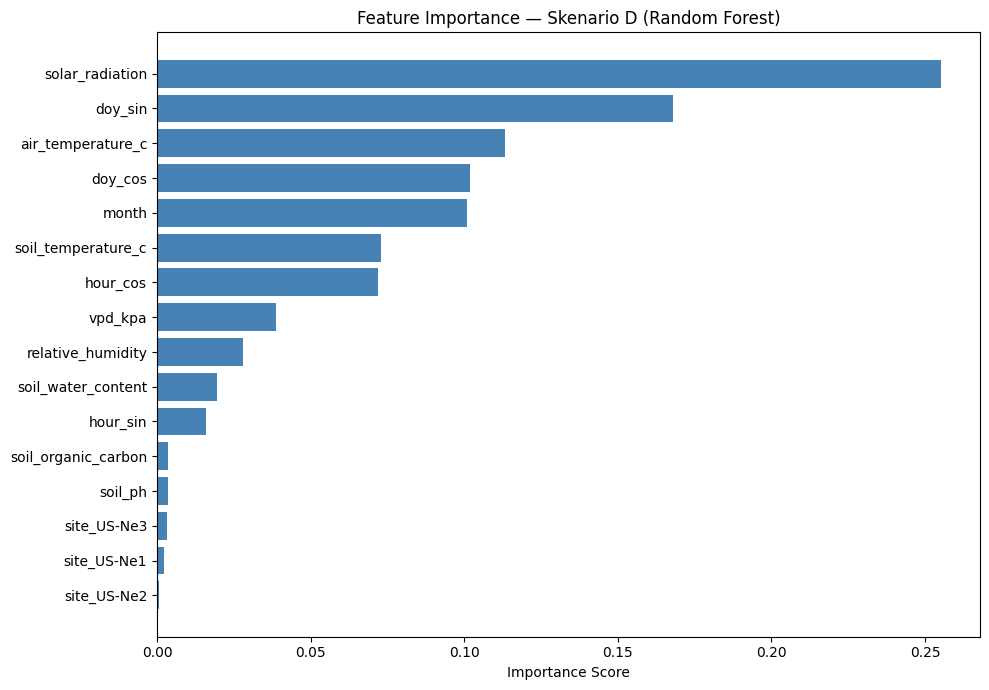

Top 10 fitur:
           feature  importance
   solar_radiation      0.2551
           doy_sin      0.1681
 air_temperature_c      0.1133
           doy_cos      0.1019
             month      0.1008
soil_temperature_c      0.0728
          hour_cos      0.0721
           vpd_kpa      0.0389
 relative_humidity      0.0279
soil_water_content      0.0196


In [28]:
# --- Feature Importance ---
fi_df = plot_feature_importance(
    best_model,
    feature_names=ALL_FEATURES,
    title=f'Feature Importance — Skenario D ({best_model_name})',
    top_n=20
)

print('Top 10 fitur:')
print(fi_df.head(10).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

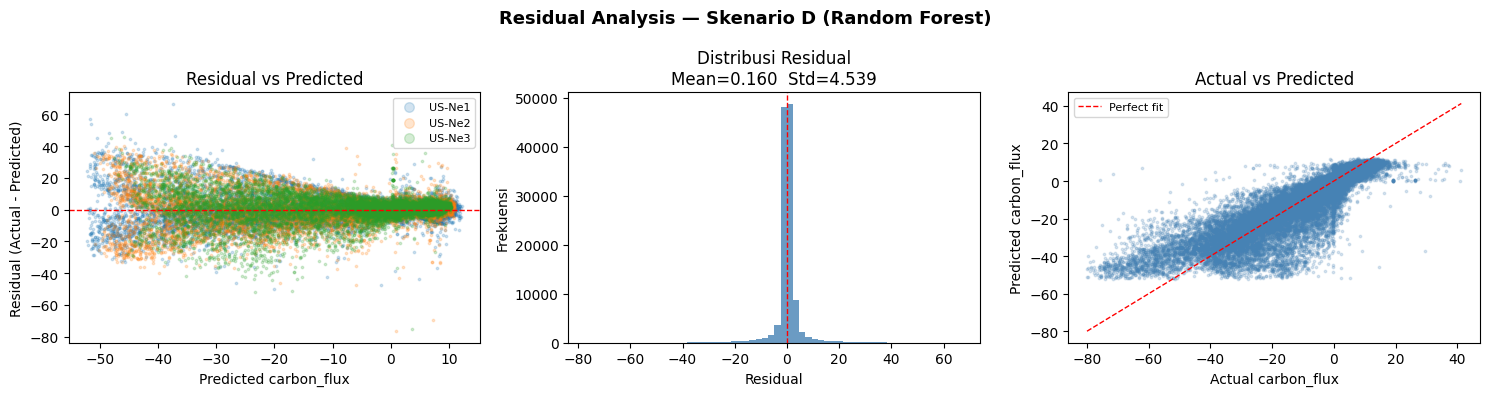

In [29]:
# --- Residual Analysis — PERBAIKAN vs SEMUA SKENARIO SEBELUMNYA ---

# Dapatkan label site untuk test set
site_test_labels = None
if len(SITE_FEATURES) > 0:
    site_test_labels = np.array([
        next(col.replace('site_', '') for col in SITE_FEATURES if test_df[col].iloc[i] == 1)
        for i in range(len(test_df))
    ])

plot_residuals(
    y_test, y_pred_best,
    title=f'Residual Analysis — Skenario D ({best_model_name})',
    site_labels=site_test_labels
)

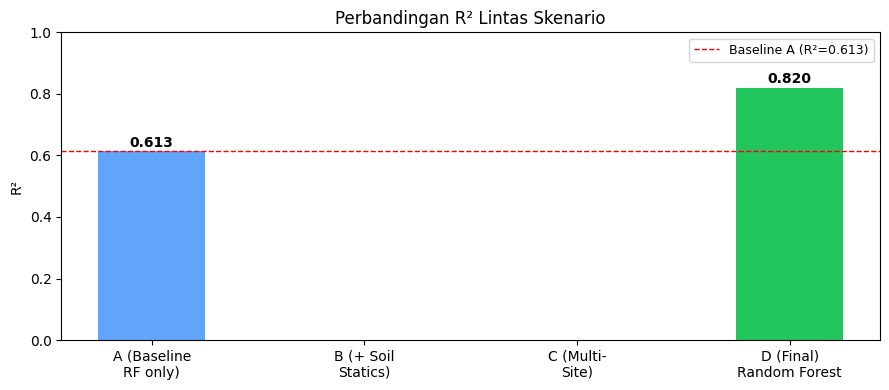

In [30]:
# --- Perbandingan R² lintas skenario ---

scenarios = {
    'A (Baseline\nRF only)': 0.613,
    'B (+ Soil\nStatics)':   None,  # Isi setelah run Skenario B
    'C (Multi-\nSite)':      None,  # Isi setelah run Skenario C
    f'D (Final)\n{best_model_name}': rf_test_r2 if best_model_name == 'Random Forest' else xgb_test_r2,
}

labels = list(scenarios.keys())
values = [v if v is not None else 0 for v in scenarios.values()]
colors = ['#94a3b8' if v is None else ('#22c55e' if i == len(labels)-1 else '#60a5fa')
          for i, v in enumerate(scenarios.values())]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='none', width=0.5)
ax.axhline(BASELINE_R2, color='red', linewidth=1, linestyle='--', label=f'Baseline A (R²={BASELINE_R2})')
for bar, val in zip(bars, scenarios.values()):
    if val is not None:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('R²')
ax.set_title('Perbandingan R² Lintas Skenario')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'perbandingan_skenario_r2.png', dpi=120)
plt.show()

---
## Bagian 9 — Export Model & Metadata

In [31]:
# =============================================================
# EXPORT MODEL — PERBAIKAN vs SEMUA SKENARIO SEBELUMNYA
# Simpan model + metadata lengkap agar dapat direproduksi
# dan siap digunakan oleh backend Laravel
# =============================================================

model_path = OUTPUT_DIR / f'carbon_flux_model_skenario_d.pkl'
meta_path  = OUTPUT_DIR / f'carbon_flux_model_skenario_d_metadata.json'

# Simpan model
joblib.dump(best_model, model_path)

# Buat metadata lengkap
metadata = {
    'skenario'          : 'D',
    'model_type'        : best_model_name,
    'best_params'       : rf_search.best_params_ if best_model_name == 'Random Forest' else xgb_search.best_params_,
    'feature_names'     : ALL_FEATURES,
    'feature_count'     : len(ALL_FEATURES),
    'target'            : TARGET,
    'sites_used'        : list(available_sites.keys()),
    'train_size'        : len(X_train),
    'test_size'         : len(X_test),
    'metrics_test'      : {
        'MAE' : float(rf_metrics['MAE']  if best_model_name == 'Random Forest' else xgb_metrics['MAE']),
        'RMSE': float(rf_metrics['RMSE'] if best_model_name == 'Random Forest' else xgb_metrics['RMSE']),
        'R2'  : float(rf_test_r2         if best_model_name == 'Random Forest' else xgb_test_r2),
    },
    'metrics_train_r2'  : float(rf_train_r2 if best_model_name == 'Random Forest' else xgb_train_r2),
    'overfit_gap'       : float(rf_gap      if best_model_name == 'Random Forest' else xgb_gap),
    'baseline_r2_skenario_a': BASELINE_R2,
    'soil_lookup'       : {k: {kk: vv for kk, vv in v.items() if kk != '_source'}
                           for k, v in soil_lookup.items()},
    'preprocessing_notes': [
        'Ganti -9999 dengan NaN sebelum semua operasi',
        'Hapus semua kolom _QC untuk mencegah data leakage',
        'Gunakan cyclical encoding untuk hour dan day_of_year',
        'Fitur soil_ph dan soil_organic_carbon konstan per site_id',
        'site_id harus di-one-hot-encode sebelum prediksi',
    ]
}

with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Model disimpan ke  : {model_path}')
print(f'✅ Metadata disimpan ke: {meta_path}')
print(f'\n   Model size: {model_path.stat().st_size / 1024:.1f} KB')

✅ Model disimpan ke  : output_skenario_d\carbon_flux_model_skenario_d.pkl
✅ Metadata disimpan ke: output_skenario_d\carbon_flux_model_skenario_d_metadata.json

   Model size: 1001762.6 KB


---
## Bagian 10 — Uji Prediksi Payload IoT (Simulasi Deployment)

In [32]:
# =============================================================
# SIMULASI PAYLOAD IoT — seperti yang diterima backend Laravel
# PERBAIKAN: memastikan preprocessing payload konsisten dengan training
# =============================================================

def preprocess_iot_payload(payload: dict, soil_lookup: dict, site_features: list) -> pd.DataFrame:
    """
    Konversi payload JSON dari perangkat IoT menjadi input model.
    
    Format payload yang diharapkan:
    {
        "site_id"           : "US-Ne1",
        "reading_time"      : "2024-07-15T14:30:00",
        "air_temperature_c" : 28.5,
        "relative_humidity" : 65.0,
        "soil_temperature_c": 22.0,
        "soil_water_content": 0.30,
        "solar_radiation"   : 650.0,
        "vpd_kpa"           : 1.2
    }
    """
    site_id = payload.get('site_id', 'US-Ne1')
    dt      = pd.to_datetime(payload['reading_time'])

    # Temporal features
    hour       = dt.hour
    doy        = dt.dayofyear
    month      = dt.month
    hour_sin   = np.sin(2 * np.pi * hour / 24)
    hour_cos   = np.cos(2 * np.pi * hour / 24)
    doy_sin    = np.sin(2 * np.pi * doy  / 365.25)
    doy_cos    = np.cos(2 * np.pi * doy  / 365.25)

    # Soil static features dari lookup
    soil = soil_lookup.get(site_id, {})

    row = {
        'air_temperature_c' : payload.get('air_temperature_c',  np.nan),
        'relative_humidity' : payload.get('relative_humidity',  np.nan),
        'soil_temperature_c': payload.get('soil_temperature_c', np.nan),
        'soil_water_content': payload.get('soil_water_content', np.nan),
        'solar_radiation'   : payload.get('solar_radiation',    np.nan),
        'vpd_kpa'           : payload.get('vpd_kpa',            np.nan),
        'hour_sin'   : hour_sin,
        'hour_cos'   : hour_cos,
        'doy_sin'    : doy_sin,
        'doy_cos'    : doy_cos,
        'month'      : month,
        'soil_ph'               : soil.get('soil_ph',             np.nan),
        'soil_organic_carbon'   : soil.get('soil_organic_carbon', np.nan),
    }

    # One-hot site features
    for sf in site_features:
        row[sf] = 1 if sf == f'site_{site_id}' else 0

    df_row = pd.DataFrame([row])

    # Imputasi NaN dengan median training jika ada nilai hilang
    for col in df_row.columns:
        if df_row[col].isna().any():
            median_val = X_train[col].median()
            df_row[col] = df_row[col].fillna(median_val)
            print(f'  ⚠️  {col} diimputasi dengan median training: {median_val:.4f}')

    return df_row[ALL_FEATURES]


# --- Uji dengan beberapa payload simulasi ---
test_payloads = [
    {
        'site_id'            : 'US-Ne1',
        'reading_time'       : '2024-07-15T14:00:00',  # Siang musim panas
        'air_temperature_c'  : 32.5,
        'relative_humidity'  : 55.0,
        'soil_temperature_c' : 26.0,
        'soil_water_content' : 0.28,
        'solar_radiation'    : 750.0,
        'vpd_kpa'            : 1.8,
    },
    {
        'site_id'            : 'US-Ne1',
        'reading_time'       : '2024-07-15T02:00:00',  # Malam hari
        'air_temperature_c'  : 18.0,
        'relative_humidity'  : 80.0,
        'soil_temperature_c' : 21.0,
        'soil_water_content' : 0.32,
        'solar_radiation'    : 0.0,
        'vpd_kpa'            : 0.3,
    },
    {
        'site_id'            : 'US-Ne3',
        'reading_time'       : '2024-01-20T12:00:00',  # Musim dingin
        'air_temperature_c'  : -5.0,
        'relative_humidity'  : 88.0,
        'soil_temperature_c' : 2.0,
        'soil_water_content' : 0.40,
        'solar_radiation'    : 120.0,
        'vpd_kpa'            : 0.1,
    },
]

print('=== Uji Prediksi Payload IoT (Simulasi) ===')
print()
loaded_model = joblib.load(model_path)

for i, payload in enumerate(test_payloads, 1):
    dt   = pd.to_datetime(payload['reading_time'])
    desc = f"Site={payload['site_id']}, {dt.strftime('%Y-%m-%d %H:%M')}, T={payload['air_temperature_c']}°C, SW_IN={payload['solar_radiation']}"
    X_payload = preprocess_iot_payload(payload, soil_lookup, SITE_FEATURES)
    pred = loaded_model.predict(X_payload)[0]
    status = 'SINK (menyerap CO₂)' if pred < 0 else 'SOURCE (melepas CO₂)'
    print(f'  Payload {i}: {desc}')
    print(f'  → Prediksi carbon_flux: {pred:.4f} µmol CO₂/m²/s  [{status}]')
    print()

=== Uji Prediksi Payload IoT (Simulasi) ===

  Payload 1: Site=US-Ne1, 2024-07-15 14:00, T=32.5°C, SW_IN=750.0
  → Prediksi carbon_flux: -44.0522 µmol CO₂/m²/s  [SINK (menyerap CO₂)]

  Payload 2: Site=US-Ne1, 2024-07-15 02:00, T=18.0°C, SW_IN=0.0
  → Prediksi carbon_flux: 6.2885 µmol CO₂/m²/s  [SOURCE (melepas CO₂)]

  Payload 3: Site=US-Ne3, 2024-01-20 12:00, T=-5.0°C, SW_IN=120.0
  → Prediksi carbon_flux: 0.2238 µmol CO₂/m²/s  [SOURCE (melepas CO₂)]



---
## Ringkasan Akhir

In [33]:
# =============================================================
# RINGKASAN EKSEKUTIF SKENARIO D
# =============================================================

best_r2  = rf_test_r2 if best_model_name == 'Random Forest' else xgb_test_r2
best_gap = rf_gap     if best_model_name == 'Random Forest' else xgb_gap

print('=' * 65)
print('  RINGKASAN EKSEKUTIF — SKENARIO D')
print('=' * 65)
print(f'  Model terbaik  : {best_model_name}')
print(f'  Test R²        : {best_r2:.4f}  (baseline Skenario A: {BASELINE_R2})')
print(f'  Delta vs A     : {best_r2 - BASELINE_R2:+.4f}')
print(f'  MAE            : {rf_metrics["MAE"]:.4f}  µmol CO₂/m²/s' if best_model_name == 'Random Forest' else f'  MAE            : {xgb_metrics["MAE"]:.4f}')
print(f'  RMSE           : {rf_metrics["RMSE"]:.4f}  µmol CO₂/m²/s' if best_model_name == 'Random Forest' else f'  RMSE           : {xgb_metrics["RMSE"]:.4f}')
print(f'  Train-Test gap : {best_gap:.4f}  ({"✅ Baik" if best_gap < 0.10 else "⚠️  Perlu perhatian"})')
print(f'  Site digunakan : {list(available_sites.keys())}')
print(f'  Total fitur    : {len(ALL_FEATURES)}')
print()
print('  File output:')
print(f'    Model  → {model_path}')
print(f'    Meta   → {meta_path}')
print('=' * 65)

print('\n  Perbaikan utama vs Skenario A:')
improvements = [
    '✅ Ditambahkan solar_radiation (SW_IN) — fitur korelasi tertinggi',
    '✅ Ditambahkan vpd_kpa — mengontrol penutupan stomata',
    '✅ Cyclical encoding hour_sin/cos, doy_sin/cos',
    '✅ Hyperparameter tuning via RandomizedSearchCV',
    '✅ Overfitting check (train vs test R²)',
    '✅ Cross-validation TimeSeriesSplit 5-fold',
    '✅ Evaluasi per site (tidak hanya global)',
    '✅ Residual analysis plot',
    '✅ Model export .pkl + metadata JSON',
    '✅ Uji prediksi payload IoT simulasi',
]
for item in improvements:
    print(f'    {item}')

  RINGKASAN EKSEKUTIF — SKENARIO D
  Model terbaik  : Random Forest
  Test R²        : 0.8196  (baseline Skenario A: 0.613)
  Delta vs A     : +0.2066
  MAE            : 1.9923  µmol CO₂/m²/s
  RMSE           : 4.5414  µmol CO₂/m²/s
  Train-Test gap : 0.1181  (⚠️  Perlu perhatian)
  Site digunakan : ['US-Ne1', 'US-Ne2', 'US-Ne3']
  Total fitur    : 16

  File output:
    Model  → output_skenario_d\carbon_flux_model_skenario_d.pkl
    Meta   → output_skenario_d\carbon_flux_model_skenario_d_metadata.json

  Perbaikan utama vs Skenario A:
    ✅ Ditambahkan solar_radiation (SW_IN) — fitur korelasi tertinggi
    ✅ Ditambahkan vpd_kpa — mengontrol penutupan stomata
    ✅ Cyclical encoding hour_sin/cos, doy_sin/cos
    ✅ Hyperparameter tuning via RandomizedSearchCV
    ✅ Overfitting check (train vs test R²)
    ✅ Cross-validation TimeSeriesSplit 5-fold
    ✅ Evaluasi per site (tidak hanya global)
    ✅ Residual analysis plot
    ✅ Model export .pkl + metadata JSON
    ✅ Uji prediksi payload I